<a href="https://colab.research.google.com/github/carmenbonal/2526_Computacional/blob/main/voluntarios/Voluntario_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Formación de las galaxias a partir de sistemas solares**

**Resumen**

Este ejercicio consiste en simular la evolución de una galaxia, compuesta por un agujero negro supermasivo central, y N sistemas solares en órbita. Se considera la atracción central del agujero negro y las interacciones entre sistemas solares. Por eficiencia, la interacción entre sistemas solares solo se calculará para sistemas cercanos entre sí. La dinámica esta regida por la segunda Ley de Newton, teniendo en cuenta las posibles colisiones elásticas, en las que se conserva la energía cinética y el momento lineal. Se implementa el algoritmo de Verlet en Velocidad. La elección de este método se basa en su eficiencia computacional, pero sobretodo en que garantiza la conservación de la energía y momento angular. Se analizará la evolución del momento angular del sistema, la densidad de Masa Radial, y el Flujo de Masa.


## 1. Fundamento teórico

*1. Dinámica del sistema de N Cuerpos*

El modelo describe una galaxia, compuesta por un agujero negro masivo centrall, y N pequeños cuerpos (sistemas solares), orbitando alrededor de éste con diferentes energías y excentricidades. La evolución de cada cuerpo $i$ viene dada por la segunda ley de Newton:
$$m_{i}\frac{d^{2}r_{i}}{dt^{2}}=-Gm_{i}\frac{M_{BH}r_i}{|r_i|^3} - Gm_{i}\sum_{j\ne i}\frac{m_{j}(r_{i}-r_{j})}{|r_{i}-r_{j}|^{3}}$$

*2. Algoritmo de Verlet en Velocidad*

Para resolver numéricamente estas ecuaciones diferenciales, empleamos el algoritmo de Verlet en velocidad, basado en el desarrollo de Taylor de la posición y la velocidad.

$$r(t+h)=r(t)+hv(t)+\frac{h^{2}}{2}a(t)$$$$v(t+h)=v(t)+\frac{h}{2}[a(t)+a(t+h)]$$

Este algoritmo conserva en media la energía cinética y el momento angular del sistema, crítico para asegurar que la dinámica observada sea físicamente real.


## 2. Metodología y Herramientas
La implementación de este simulador se ha realizado mediante una colaboración con el modelo de lenguaje Gemini, que ha actuado como herramienta de apoyo para el desarrollo de un motor de dinámica de N cuerpos en Python. A través de este proceso, la IA facilitó la integración del algoritmo de Verlet en velocidad, un integrador simpléctico fundamental para garantizar la conservación del momento angular y la energía en un sistema compuesto por un agujero negro supermasivo y múltiples sistemas solares. Además de estructurar el cálculo de las interacciones gravitatorias —incluyendo el parámetro de suavizado (softening) para evitar singularidades—, Gemini asistió en la creación de una visualización dinámica mediante matplotlib.animation.

## 2.1 Prompt de Diseño
Para asegurar la obtención de un código eficiente y físicamente riguroso, se establecieron las siguientes especificaciones:

> * **Objetivo**: Implementación matricial del algoritmo de Verlet en velocidad para N cuerpos:
>   1. Cálculo de posiciones futuras:$$r(t+h) = r(t) + v(t)h + \frac{1}{2}a(t)h^2$$
>   2. Evaluación de la nueva aceleración gravitatoria:$$a(t+h)$$(Atracción central del agujero negro + interacciones locales vectorizadas con suavizado).
>   3. Corrección de velocidades:$$v(t+h) = v(t) + \frac{1}{2}[a(t) + a(t+h)]h$$
> * **Análisis de los resultados:** El sistema debe alcanzar un estado estacionario tras una fase de relajación inicial. Se requiere extraer observables macroscópicos del sistema: evolución del momento de inercia, cálculo de la distribución radial de densidad estelar y flujo de masa absorbida por el centro galáctico.
> * **Entorno y librerías:** Ejecución en formato Jupyter/Colab. Uso exclusivo de numpy mediante broadcasting para evitar bucles anidados en el cálculo de fuerzas, y matplotlib para la exportación de resultados y generación de animaciones en formato GIF.




**Estructura y Funcionamiento del Código**


Primero, configuramos el modelo. Añadimos un tiempo de relajación. Esto se debe a que los sistemas solares necesitan un tiempo para alcanzar el estado estacionario. Durante este periodo de relajación, el sistema es inestable y los observables oscilan bruscamente.
También añadimos el parámetro SOftening en el denominador de la ley de gravitación para evitar q la fuerza se vuelva infinita cuando la distancia entre masas se acerca a cero, lo cual colapsaría la simulación.

In [13]:
import numpy as np # Para el cálculo científico
import matplotlib.pyplot as plt # Para visualización
import matplotlib.animation as animation # Para crear animaciones en GIF

N_SISTEMAS = 100    #Cantidad de sistemas solares simulados
G = 1.0             # Constante gravitacional en unidades naturales
M_AGUJERO_NEGRO = 2000.0  # Masa del agujero negro central
M_SISTEMA = 1.0          # Masa de cada sistema solar
R_SISTEMA = 0.3     # Radio de cada sistema solar
R_COLISION = 0.06  # Radio de colisión
R_ABSORCION = 0.8 # Radio de absorción
R_FRONTERA = 8.0    # Radio de la frontera
DIST_INTERACCION = 3.0 # Distancia a partir de la cual se consideran interacciones
DT = 0.005 # Paso
SOFTENING = 0.1 # Para evitar que la fuerza se vuelva infinita
PASOS_ESTABILIZACION = 10000
PASOS_MEDICION = 10000
COLA = 200

Damos una velocidad inicial a los sistemas solares para que estos no caigan directamente en el agujero negro. Usamos la formula de la velocidad obtenida al igualar la fuerza centrípeta y la gravitatoria: $v = \sqrt{GM/r}$. Es decir, los sistemas tendrán una órbita circular, al menos al principio, para que no colapse directamente. La excentricidad se da de forma natural con el tiempo, debido a la interacción gravitatoria.
Las posiciones iniciales de los sistemas también se dan de forma aleatoria inicialmente.

Calculamos la aceleración con la ley de Newton en cada instante con la siguiente función:


In [14]:

def get_acc(pos, mass, m_bh, r_limit):

    acc = np.zeros_like(pos)
    r_mag_bh = np.linalg.norm(pos, axis=1).reshape(-1, 1)

    # Gravedad del agujero negro
    acc -= G * m_bh * pos / (r_mag_bh**3 + SOFTENING)

    # Interacciones locales
    for i in range(len(pos)):
        for j in range(i + 1, len(pos)):

            diff = pos[j] - pos[i]
            dist = np.linalg.norm(diff)

            if dist < r_limit and dist > 0:
                force = G * mass * diff / (dist**3 + SOFTENING)
                acc[i] += force
                acc[j] -= force

    return acc

Ahora creamos una función para los choques eásticos entre sistemas: 

In [15]:

def resolver_colisiones(pos, vel, r_col):

    for i in range(len(pos)):
        for j in range(i + 1, len(pos)):

            diff = pos[j] - pos[i]
            dist = np.linalg.norm(diff)

            if dist < 2 * r_col and dist > 0:
                normal = diff / dist
                rel_vel = vel[j] - vel[i]
                v_impulse = np.dot(rel_vel, normal)

                if v_impulse < 0:
                    vel[i] += v_impulse * normal
                    vel[j] -= v_impulse * normal


En la función principal, generamos una posición inicial aleatoria a cada sistema. Para cada posición, calcula la velocidad que necesitaría para que esta tenga una órbita circular. Al multiplicarla por un factor aleatorio positivo inferior a 1, conseguimos que sigan órbitas elípticas. Luego calculamos el vector perpendicular a su posición para aplicar esta velocidad tangencial. 

Antes de entrar en el algoritmo de Verlet, ejecutamos la función aceleración para obtener los valores iniciales. Preparamos listas en blanco para guardar los datos y preparar el gráfico sobre el que se dibujará la simulación. Luego empezará el bucle de Verlet, siguiendo los pasos explicados en el fundamento teórico. La línea idx = step % COLA utiliza una operación de módulo para guardar las nuevas posiciones cíclicamente en el registro sin que el array crezca infinitamente.

A continuación imponemos condiciones de contorno: si una partícula se acerca demasiado al agujero negro, es absorbida y reintroducida en la frontera del sistema. Si por el contrario cruza el borde de la frontera, la volveremos a reintroducir. 

Una vez terminado el periodo de estabilización, empieza el cálculo de parámetros. Calcularemos el momento de inercia y la densidad radial.
Por último se toman las imagenes generadas cada 40 pasos y usa la librería animation para empaquetarlas en un archivo simulacion.gif.

Fase 1: Calculando simulación y fotogramas...


KeyboardInterrupt: 

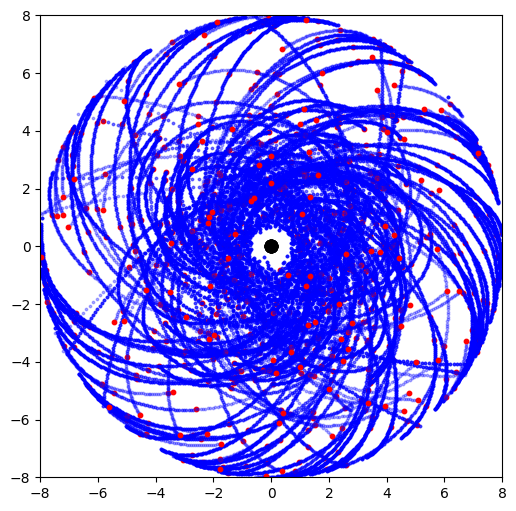

In [16]:

def main():

    # -------------------------------------------------
    # INICIALIZACIÓN
    # -------------------------------------------------

    pos = np.random.uniform(
        -R_FRONTERA * 0.6,
        R_FRONTERA * 0.6,
        (N_SISTEMAS, 2)
    )

    vel = np.zeros_like(pos)

    for i in range(N_SISTEMAS):
        r = np.linalg.norm(pos[i])
        if r == 0:
            r = 1e-6

        v_circular = np.sqrt(G * M_AGUJERO_NEGRO / r)
        factor = np.random.uniform(0.4, 0.8)
        v_mag = v_circular * factor
        direccion = np.array([-pos[i, 1], pos[i, 0]]) / r
        
        vel[i] = direccion * v_mag
        vel[i] += np.random.normal(0, 0.05, 2)

    acc = get_acc(pos, M_SISTEMA, M_AGUJERO_NEGRO, DIST_INTERACCION)

    absorciones = 0
    historial_inercia = []
    historial_densidad = []
    total_steps = PASOS_ESTABILIZACION + PASOS_MEDICION

    pos_save = np.zeros((N_SISTEMAS, 2, COLA))

    print("Fase 1: Calculando simulación y fotogramas...")

    # Configuración de la figura para la animación
    fig, ax_anim = plt.subplots(figsize=(6, 6))
    ax_anim.set_xlim(-R_FRONTERA, R_FRONTERA)
    ax_anim.set_ylim(-R_FRONTERA, R_FRONTERA)
    ax_anim.set_aspect("equal")
    
    fotogramas = []

    # -------------------------------------------------
    # BUCLE TEMPORAL (VERLET)
    # -------------------------------------------------

    for step in range(total_steps):

        v_half = vel + acc * DT / 2.0
        pos += v_half * DT

        idx = step % COLA
        pos_save[:, :, idx] = pos

        # -------------------------------------------------
        # GESTIÓN DE FRONTERAS (ABSORCIÓN Y ESCAPE)
        # -------------------------------------------------

        for i in range(N_SISTEMAS):
            r_mag = np.linalg.norm(pos[i])

            # Si la partícula cae al agujero negro o escapa de la frontera
            if r_mag < R_ABSORCION or r_mag > R_FRONTERA:
                
                # Contabilizar absorción solo si cruzó el límite interior
                if step >= PASOS_ESTABILIZACION and r_mag < R_ABSORCION:
                    absorciones += 1

                # Regenerar la partícula en la frontera
                theta = np.random.uniform(0, 2 * np.pi)
                pos[i] = R_FRONTERA * np.array([np.cos(theta), np.sin(theta)])
                v_circular = np.sqrt(G * M_AGUJERO_NEGRO / R_FRONTERA)
                factor = np.random.uniform(0.4, 0.8)
                v_reg = v_circular * factor
                direccion = np.array([-pos[i, 1], pos[i, 0]]) / R_FRONTERA
                
                vel[i] = direccion * v_reg
                vel[i] += np.random.normal(0, 0.2, 2)
                v_half[i] = vel[i]

        resolver_colisiones(pos, v_half, R_COLISION)

        acc_new = get_acc (pos, M_SISTEMA, M_AGUJERO_NEGRO, DIST_INTERACCION)

        vel = v_half + acc_new * DT / 2.0
        acc = acc_new

        # -------------------------------------------------
        # VISUALIZACIÓN DE TRAYECTORIAS (Guardado de fotogramas)
        # -------------------------------------------------

        if step % 40 == 0:  # Guardar fotograma cada 40 pasos

            elementos_fotograma = []

            for i in range(N_SISTEMAS):
                if step < COLA:
                    trayectoria = pos_save[i, :, :step]
                else:
                    trayectoria = np.concatenate((
                        pos_save[i, :, idx:],
                        pos_save[i, :, :idx]
                    ), axis=1)

                if trayectoria.shape[1] > 0:
                    pts_tray = ax_anim.scatter(trayectoria[0], trayectoria[1], s=3, color='blue', alpha=0.3)
                    elementos_fotograma.append(pts_tray)

            pts_pos = ax_anim.scatter(pos[:, 0], pos[:, 1], s=10, color='red')
            pts_bh = ax_anim.scatter(0, 0, s=80, color='black')
            
            elementos_fotograma.extend([pts_pos, pts_bh])
            fotogramas.append(elementos_fotograma)

        # -------------------------------------------------
        # MEDICIONES
        # -------------------------------------------------

        if step >= PASOS_ESTABILIZACION:

            I = np.sum(M_SISTEMA * np.sum(pos**2, axis=1))
            historial_inercia.append(I)

            radios = np.linalg.norm(pos, axis=1)
            counts, bins = np.histogram(radios, bins=20, range=(0, R_FRONTERA))
            areas = np.pi * (bins[1:]**2 - bins[:-1]**2)
            densidad = counts * M_SISTEMA / areas
            historial_densidad.append(densidad)

    # -------------------------------------------------
    # COMPILACIÓN DEL VÍDEO
    # -------------------------------------------------
    print("Compilando animación...")
    ani = animation.ArtistAnimation(fig, fotogramas, interval=50, blit=True)
    ani.save("simulacion.gif", writer="pillow")
    plt.close(fig) 

    # -------------------------------------------------
    # RESULTADOS
    # -------------------------------------------------

    tiempo_total = PASOS_MEDICION * DT
    flujo_masa = (absorciones * M_SISTEMA) / tiempo_total
    densidad_media = np.mean(historial_densidad, axis=0)
    inercia_media = np.mean(historial_inercia)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    print("\n--- RESULTADOS ---")
    print("Absorciones totales:", absorciones)
    print("Tiempo total:", tiempo_total)
    print("Flujo medio de masa:", flujo_masa)
    print("Momento de inercia medio:", inercia_media)

    # -------------------------------------------------
    # GRÁFICAS FINALES
    # -------------------------------------------------

    fig_res, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(bin_centers, densidad_media)
    ax1.set_title("Distribución radial de densidad")
    ax1.set_xlabel("Radio")
    ax1.set_ylabel("Densidad")

    ax2.plot(historial_inercia)
    ax2.set_title("Evolución del momento de inercia")
    ax2.set_xlabel("Pasos de medición")
    ax2.set_ylabel("I")

    plt.tight_layout()
    plt.savefig("analisis_galaxia.png")
    plt.show()

if __name__ == "__main__":
    main()



![Simulación](simulacion.gif)

**Evaluación de resultados**


*1. Distribución radial de densidad*

Observamos que el gráfico muestra una densidad nula hasta un radio de 0.9. Esto valida la condición de límite inferior, en la que el agujero negro absorbe los sistemas. También vemos un pico masivo para un radio de 8. Esto se debe a que, al forzar que las partículas absorbidas reaparezcan en la frontera, creamos una zona de acumulación estelar. En una galaxia real, la densidad decae de forma progresiva y suave hacia el exterior.

*2. Evolución del momento de inercia*

Vemos que el sistema llega a un estado estacionario, donde la gráfica oscila pero sin mostrar una tendencia al alza o a la baja, lo que confirma que el sistema no está colapsando hacia el centro, ni explotando hacia el infinito, y que la fase de relajación cumplió su proposito. 

*3. Evolución temporal de las trayectorias*

Al representar las trayectorias de los sistemas, somos capaces de reforzar la confirmación de que el sistema no colapsa, sino que llega a un estado estacionario.  